# Is the stock market's whole reward earned on a few macro-news days? 📅
### The Savor-Wilson announcement-day premium, retried on the modern tape — in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![All_just_FOMC%3F: Confirmed](https://img.shields.io/badge/All_just_FOMC%3F-Confirmed-8b949e?style=flat-square)

Every month, on days everyone knows about **months in advance**, the US government publishes its biggest economic numbers: the **CPI** (inflation), the **jobs report** ("NFP"), and the Fed's **FOMC decision**. A famous 2013 academic paper (Savor & Wilson) claimed something remarkable: **most of the stock market's entire long-run reward is earned on precisely those days** — about one day in eight.

If that's true, it sounds like the cheat code of the century: be invested on ~31 scheduled days a year, sit in cash the rest, sleep well. We rebuilt the whole thing on 29.5 years of real prices with the actual, dated release calendar. Short version: the silhouette of the effect is there — but the honest version doesn't survive the audit, and the trade definitely doesn't.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** Real data: SPY (and TLT) total-return closes, 1997→2026, against a hardcoded calendar of **actual** FOMC/CPI/NFP release dates (sources in [`data.py`](../macro_announcement_premium/data.py)). Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from macro_announcement_premium import data, strategy as st

START, ASOF = "1997-01-01", "2026-06-30"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX = data.load_real()
    PX = PX[(PX.index >= "1996-12-01") & (PX.index <= ASOF)]
    RET = st.daily_returns(PX["SPY"].dropna())
    RET = RET[RET.index >= START]
    MASKS = data.announcement_masks(RET.index)
else:
    PX = RET = MASKS = None
print("real cache present:", HAVE_REAL,
      "| daily returns:", (0 if RET is None else len(RET)),
      "| A-days:", (0 if MASKS is None else int(MASKS["ANY"].sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1997-01-02', 'end': '2026-06-30', 'years': 29.5, 'n_days': 7419, 'n_fomc': 236, 'n_cpi': 353, 'n_nfp': 353, 'n_adays': 923, 'frac_days': 12.4, 'n_overlap': 19, 'n_mapped': 10, 'a_mean_bps': 10.63, 'rest_mean_bps': 3.69, 'diff_bps': 6.94, 'welch_t': 1.57, 'a_t0': 2.55, 'share_return': 32.1, 'p_placebo': 0.0563, 'types': [('FOMC', 236, 22.2, 18.52, 2.25), ('CPI', 353, 4.55, 0.87, 0.12), ('NFP', 353, 13.24, 9.56, 1.38)], 'decades': [('1997-2006', 13.92, 2.46, 11.46, 1.51, 315), ('2007-2016', 14.05, 2.01, 12.04, 1.56, 312), ('2017-2026', 3.53, 6.75, -3.22, -0.42, 296)], 'tlt': {'a': -0.56, 'rest': 2.18, 'diff': -2.74, 't': -0.68, 'n': 749, 'days': 6016}, 'overlay': [(1.0, 10.63, 8.63, 2.07, 2.48, 10.05), (2.0, 10.63, 6.63, 1.59, 1.84, 10.05), (5.0, 10.63, 0.63, 0.15, -0.05, 10.05)], 'exfomc': {'mean': 6.65, 'diff': 2.97, 't': 0.58, 'n': 687, 'p': 0.3175}, 'fomc_leg': {'mean': 22.2, 'diff': 18.52, 't': 2.25, 'n': 236}, 'fomc_decades': [('1997-2006', 14.28, 1.21, 80), ('2007-2016', 45.29, 2.9, 80), ('2017-2026', -6.09, -0.41, 76)], 'syn': [(0.0, 0.45, 0.1, 4), (20.0, 20.45, 4.72, 100)], 'fingerprint': 'e42015f7ee3e'}


real cache present: True | daily returns: 7419 | A-days: 923


## The answer first

| Question | Answer |
|---|---|
| Do announcement days earn more? | **On average yes** — about **+11 bps** vs **+4 bps** on ordinary days, and one-eighth of the days carried a **third** of the market's cumulative return. But that gap is **not statistically solid** (it could plausibly be luck — the quants notebook puts it right at the edge, *p* ≈ 0.06). |
| Is it CPI? Jobs day? The Fed? | **It's the Fed. Full stop.** Take the FOMC days out and the remaining CPI/jobs days earn basically the same as any other day. |
| Is it still alive? | **Not since 2017.** The gap was healthy 1997-2016 and has been slightly *negative* for the last decade. |
| Can I get rich holding stocks only on those days? | **No.** Even at near-zero trading costs the "announcement days only" strategy makes ~2.5%/yr while just holding the index made ~10%/yr — and at normal retail costs it makes **nothing**. |

> The honest verdict: a **Weak** signal (real-looking silhouette, below the significance bar, all of it Fed days, faded since 2017) and a **Mirage** to trade.

## 1 · The claim

> *"Stocks earn their risk premium when investors bear the scariest risk — and the scariest, most concentrated risk arrives on scheduled macro-announcement mornings. So the equity premium should cluster on CPI, employment and FOMC days."*

That's **Savor & Wilson (2013)**, published in a top journal on 1958-2009 data: about **+11.4 bps** on announcement days vs **+1.1 bps** on other days. The pitch is elegant because the calendar is **public months ahead** — no crystal ball needed. Our question: does it hold on the modern, tradable tape (SPY, 1997→2026), and can you eat it?

## 2 · So what?

If most of the equity premium really lands on ~31 pre-known days a year, two big things follow. For **theory**: risk premia are compensation for *event* risk, not calendar time — you get paid for holding through the scary mornings. For **practice**: an investor could hold stocks an eighth of the time and collect most of the reward — the ultimate low-effort timing strategy.

Both hinge on the premium being (a) statistically real, (b) spread across the macro calendar rather than one event type, and (c) big enough to survive trading costs. We test all three.

## 3 · How would we even know?

We hardcode the **actual release calendar** — 236 FOMC decision days (Fed historical calendars) + 353 CPI and 353 jobs-report release dates (from the BLS's own archive, cross-checked against its official historical-release-dates table; shutdown-delayed releases and holiday quirks included). That gives **923 announcement sessions** out of 7,419 trading days (12.4%). Then:

1. **Compare.** Average SPY return on announcement days vs all other days.
2. **Stress it.** Could 923 random days look this special? (20,000 random calendars.)
3. **Split it.** By type (FOMC / CPI / NFP) and by decade.
4. **Trade it.** Hold SPY *only* on announcement days, entering the night before (the schedule is public), and charge real costs.

## 4 · The teardown — let's actually look

**First, the headline gap.** Average daily return on announcement days vs the rest.

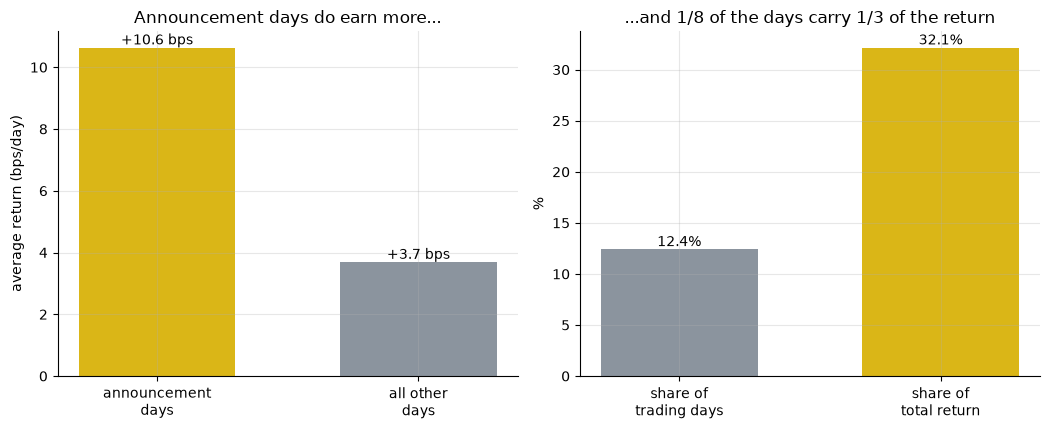

A-days +10.6 bps/day vs others +3.7; A-days = 12.4% of days, 32.1% of return


In [2]:
if HAVE_REAL:
    s = st.event_vs_rest(RET.values, MASKS['ANY'])
    am, rm, sh = s['ev_mean_bps'], s['base_mean_bps'], s['share_of_total']*100
else:
    am, rm, sh = R['a_mean_bps'], R['rest_mean_bps'], R['share_return']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.4))
a1.bar(['announcement\ndays', 'all other\ndays'], [am, rm], color=[AMBER, GREY], width=.6)
for i, v in enumerate([am, rm]): a1.annotate(f'{v:+.1f} bps', (i, v), ha='center', va='bottom')
a1.set_ylabel('average return (bps/day)'); a1.set_title('Announcement days do earn more...')
a2.bar(['share of\ntrading days', 'share of\ntotal return'], [R['frac_days'], sh], color=[GREY, AMBER], width=.6)
for i, v in enumerate([R['frac_days'], sh]): a2.annotate(f'{v:.1f}%', (i, v), ha='center', va='bottom')
a2.set_ylabel('%'); a2.set_title('...and 1/8 of the days carry 1/3 of the return')
plt.tight_layout(); plt.show()
print(f'A-days {am:+.1f} bps/day vs others {rm:+.1f}; A-days = {R["frac_days"]:.1f}% of days, {sh:.1f}% of return')

Looks impressive: **+10.6 bps** on announcement days vs **+3.7 bps** otherwise, and **12.4%** of the days carried **32.1%** of the return. But "looks impressive" is where most market legends live. The statistical test says this gap is **Welch *t* = 1.57** — *below* the desk's bar of 2, with about a **1-in-18** chance (*p* ≈ 0.056) that 923 random days would look this good. Suggestive, not proven.

**Now the twist — split it by announcement type.**

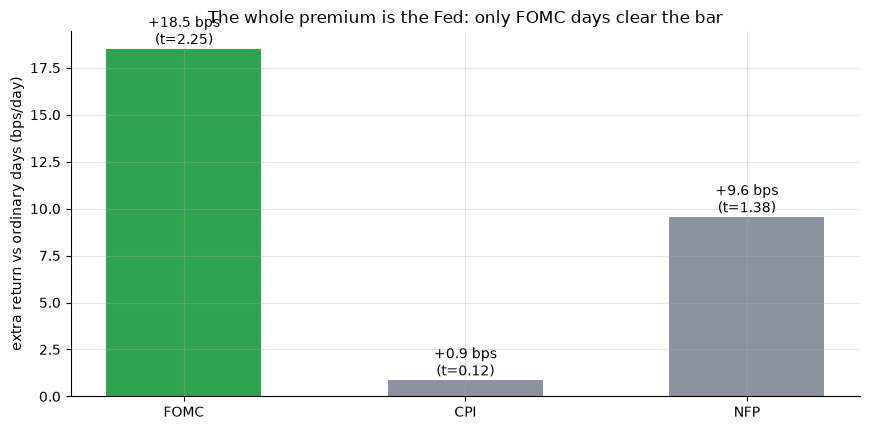

diff vs ordinary days: {'FOMC': '+18.5 bps (t=2.25)', 'CPI': '+0.9 bps (t=0.12)', 'NFP': '+9.6 bps (t=1.38)'}


In [3]:
if HAVE_REAL:
    pure = ~MASKS['ANY']
    rows = [(nm, st.event_vs_rest(RET.values, MASKS[nm], base=pure)) for nm in ('FOMC','CPI','NFP')]
    labels = [r[0] for r in rows]; diffs = [r[1]['diff_bps'] for r in rows]; ts = [r[1]['welch_t'] for r in rows]
else:
    labels = [t[0] for t in R['types']]; diffs = [t[3] for t in R['types']]; ts = [t[4] for t in R['types']]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
cols = [GREEN if t >= 2 else GREY for t in ts]
ax.bar(labels, diffs, color=cols, width=.55)
for i, (d, t) in enumerate(zip(diffs, ts)):
    ax.annotate(f'{d:+.1f} bps\n(t={t:.2f})', (i, max(d, 0)), ha='center', va='bottom')
ax.set_ylabel('extra return vs ordinary days (bps/day)')
ax.set_title('The whole premium is the Fed: only FOMC days clear the bar')
plt.tight_layout(); plt.show()
print('diff vs ordinary days:', {l: f'{d:+.1f} bps (t={t:.2f})' for l, d, t in zip(labels, diffs, ts)})

There's the reveal. **FOMC days: +18.5 bps** over an ordinary day (*t* = 2.25 — clears the bar). **CPI days: +0.9 bps** (*t* = 0.12 — nothing). NFP days lean positive but don't clear. The "macro announcement premium" is, on this tape, **the Fed-day premium wearing a bigger calendar**.

**Is it at least alive?** Same test, by decade.

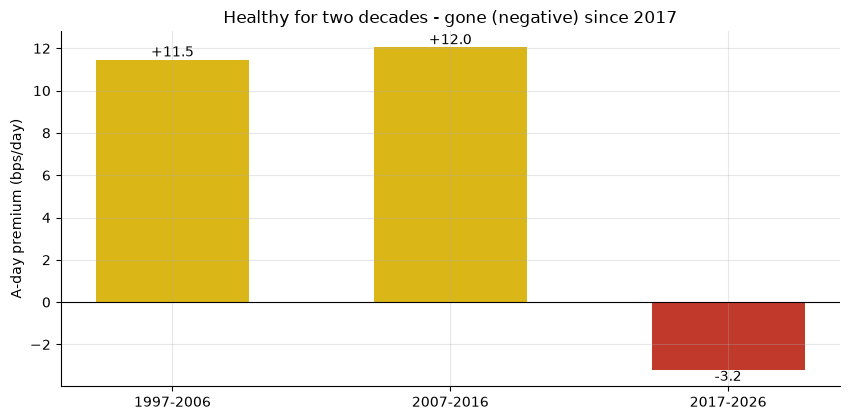

A-day premium by decade: {'1997-2006': '+11.5 bps/day', '2007-2016': '+12.0 bps/day', '2017-2026': '-3.2 bps/day'}


In [4]:
if HAVE_REAL:
    splits = [('1997-2006','1997-01-01','2006-12-31'), ('2007-2016','2007-01-01','2016-12-31'),
              ('2017-2026','2017-01-01','2026-06-30')]
    dec = st.subperiod_stats(RET, MASKS['ANY'], splits)
    labels = [d['label'] for d in dec]; diffs = [d['diff_bps'] for d in dec]
else:
    labels = [d[0] for d in R['decades']]; diffs = [d[3] for d in R['decades']]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar(labels, diffs, color=[AMBER, AMBER, RED], width=.55)
for i, v in enumerate(diffs): ax.annotate(f'{v:+.1f}', (i, v), ha='center', va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('A-day premium (bps/day)'); ax.set_title('Healthy for two decades - gone (negative) since 2017')
plt.tight_layout(); plt.show()
print('A-day premium by decade:', dict(zip(labels, [f'{v:+.1f} bps/day' for v in diffs])))

The premium lived in 1997-2016 (**+11.5** and **+12.0 bps/day**) and has been **-3.2 bps/day since 2017** — announcement days have earned *less* than ordinary days for nearly a decade.

**Finally — the money question.** Hold SPY only on announcement days (you know the schedule in advance: buy the close before, sell the close after), vs just staying invested.

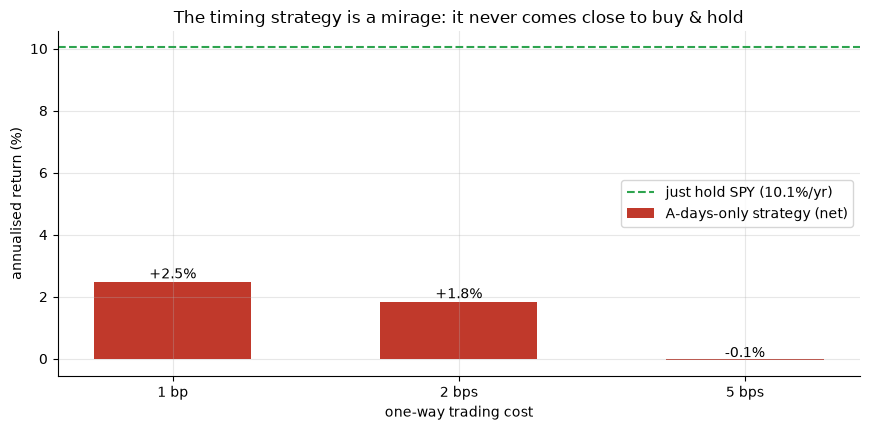

A-days-only net ann: ['+2.48%', '+1.84%', '-0.05%']  vs buy & hold 10.05%


In [5]:
if HAVE_REAL:
    rows = [st.overlay_stats(RET, MASKS['ANY'], cost_bps=cb) for cb in (1.0, 2.0, 5.0)]
    net_ann = [r['net_ann_pct'] for r in rows]; bh = rows[0]['bh_ann_pct']
else:
    net_ann = [o[4] for o in R['overlay']]; bh = R['overlay'][0][5]
fig, ax = plt.subplots(figsize=(8.8, 4.4))
ax.bar(['1 bp', '2 bps', '5 bps'], net_ann, color=RED, width=.55, label='A-days-only strategy (net)')
ax.axhline(bh, ls='--', c=GREEN, label=f'just hold SPY ({bh:.1f}%/yr)')
for i, v in enumerate(net_ann): ax.annotate(f'{v:+.1f}%', (i, v), ha='center', va='bottom')
ax.set_xlabel('one-way trading cost'); ax.set_ylabel('annualised return (%)')
ax.set_title('The timing strategy is a mirage: it never comes close to buy & hold')
ax.legend(); plt.tight_layout(); plt.show()
print('A-days-only net ann:', [f'{v:+.2f}%' for v in net_ann], ' vs buy & hold', f'{bh:.2f}%')

Even at an institutional **1 bp** per trade the strategy nets **+2.5%/yr vs 10.1%/yr** for doing nothing, and at a realistic **5 bps** it makes **-0.1%/yr** — nothing. You'd be trading ~31 round trips a year to give up three-quarters of the market's return. *(We don't even credit T-bill interest on the cash days — adding it wouldn't change the picture at retail costs.)*

## 5 · The verdict

- **Signal — Weak.** Announcement days earn more on average (**+6.9 bps/day**) and carry an outsized share of the return, but the gap sits **below the significance bar** (*t* = 1.57, *p* ≈ 0.06), is entirely a **Fed-day** effect, and has been absent since 2017.
- **Tradability — Mirage.** The announcement-days-only strategy loses to buy & hold at **every** cost level — there is nothing to deploy.
- **"Is it all just FOMC?" — Confirmed.** Strip the Fed days out and CPI/jobs days earn **+3.0 bps/day** over ordinary days (*t* = 0.58) — statistically nothing.

## 6 · Going further 🚪

- **Why did the textbook version look stronger?** Savor-Wilson's sample is 1958-2009 — the era before the modern always-on news cycle, and one that ends right at the 2008-2009 Fed-day fireworks. Post-publication decay is the oldest story in the anomaly literature.
- **The Fed-day corner is its own rabbit hole** — the desk has torn it down three ways: [pre-FOMC drift](../../517-pre-fomc-drift/README.md) (real, decayed post-2012), [Fed drift folklore](../../67-fed-drift/README.md), and the [FOMC cycle](../../135-fomc-cycle/README.md).
- **Build your own.** Swap SPY for small caps or high-beta names (Savor-Wilson predict a steeper announcement-day risk-return line), or add PPI/GDP release days — the calendar machinery in `data.py` makes that a ten-line change.

*Think the premium hides in higher-beta assets or intraday windows? The calendar is hardcoded and sourced — show us a leg that clears t = 2 out of sample, then we'll talk.*